# Q4

### (a) 
To answer this question we can imagine a kernel of width 0.1 sweeping along the X-axis from 0 to 1, where the area of the kernel around a point X corresponds to the fraction of available observations we use to make a prediction for the response of test observation X.

The following figure just helps us visualise what we mean to do. And intuitivly the result should be close to 10% since it stays 10% for all points in the range [0.05, 0.95] and slightly decreases outside that range.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

sns.set_theme()

%matplotlib inline

In [2]:
from ISLP import confusion_table
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

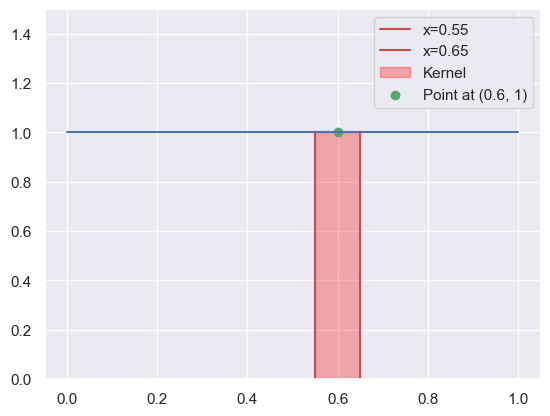

In [3]:
fig, ax = plt.subplots()
ax.set_ylim([0, 1.5])

# Plot the horizontal line
ax.plot([0, 1], [1, 1], c='b')  

# Add vertical red lines using ax.plot (absolute coordinates)
ax.plot([0.55, 0.55], [0, 1], c='r', label='x=0.55')  # Line from y=0 to y=1
ax.plot([0.65, 0.65], [0, 1], c='r', label='x=0.65')  # Line from y=0 to y=1

# Shade the area between the two vertical lines
ax.axvspan(0.55, 0.65, 0, 1/ax.get_ylim()[1], color='red', alpha=0.3, label='Kernel')

ax.scatter(0.6, 1, c='g', label='Point at (0.6, 1)')
ax.legend()

plt.show()

In [4]:
within = 0.1
lim = within/2
obs = np.linspace(0, 1, 1001)
used_obs = np.array([])
for i in obs:
    left = i - lim
    if left < 0:
        left = 0
    
    right = i + lim 
    if right > 1:
        right = 1
    # print(f'[{left:.2f}, {right:.2f}]')
    used_obs = np.append(used_obs, right - left)

0.09745254745254749

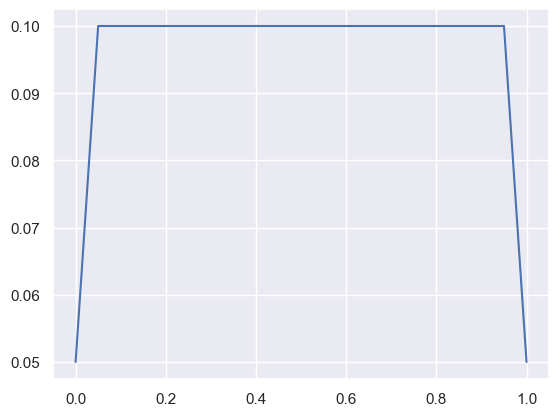

In [5]:
plt.plot(obs, used_obs);
used_obs.mean()

We can see that on average, the fraction of available observations we use to make the prediction is 9.75%

### (b) 
Extending the idea above from 2 dimensions (p = 1) to 3 dimensions (p = 2).

In [6]:
within = 0.10
lim = within/2
obs = np.arange(0, 1, 0.01)
p = 2
used_obs = []
for n in range(p):

    used_obs_dim = []
    for i in obs:
        minimum = i - lim
        if minimum < 0:
            minimum = 0
        
        max = i + lim 
        if max > 1:
            max = 1
            
        # print(f'[{min:.2f}, {max:.2f}]')
        used_obs_dim.append(max - minimum)
    used_obs.append(used_obs_dim)

used_obs = np.array(used_obs)

In [7]:
import operator 
from functools import reduce

grid = np.meshgrid(*used_obs, indexing="ij")

result = reduce(operator.mul, grid)
result.mean()

0.009506250000000008

We can see that on average we use 0.95% of the available observations to make the prediction.

### (c)
Similar to what we did above we just extend the same ideas to a 101 dimensions (p = 100). Creating the grid for the data would be troublesome so we’ll just use the fact that from every dimension we use 9.75% of the data like so.

$$
0.0975 ^ p
$$ 

In [8]:
0.0975 ** 2

0.00950625

We can see that we get the same result we calculated above for p = 2.

In [9]:
0.0975 ** 100

7.951728986183188e-102

As we can see the value is so miniscule that we’re practically using almost 0% of the available observations to make a prediction.

**(d)** Looking at our answers from (a)-(c) we can see that the more predictors we use while considering a non-parametric method like KNN, the less test observations are used to make the prediction, since data points become very sparse in higher dimensions.

**(e)** To find the sidelength of the hypercube that contains 10% of the testing observations we just need to find the sidelength of a p-dimensional hypercube that has a p-dimensional "area" of 0.10.

$$
x ^ p = 0.10
$$

for $p = 1$ that'd be:

$$
x = 0.10
$$

for $p = 2$ that'd be:

In [10]:
np.power(0.10, 1/2)

0.31622776601683794

$$
x = \sqrt[^{100}]{0.10}\\
x = 0.977
$$

We can see that for large values of p the sidelength of the hypercube gets so big to the point where it's close to 1 but only 10% of test observations fall within the hypercube, which is a testament to how sparse data in high dimensional space gets.

I'll create a plot to capture that relation for various values of p:

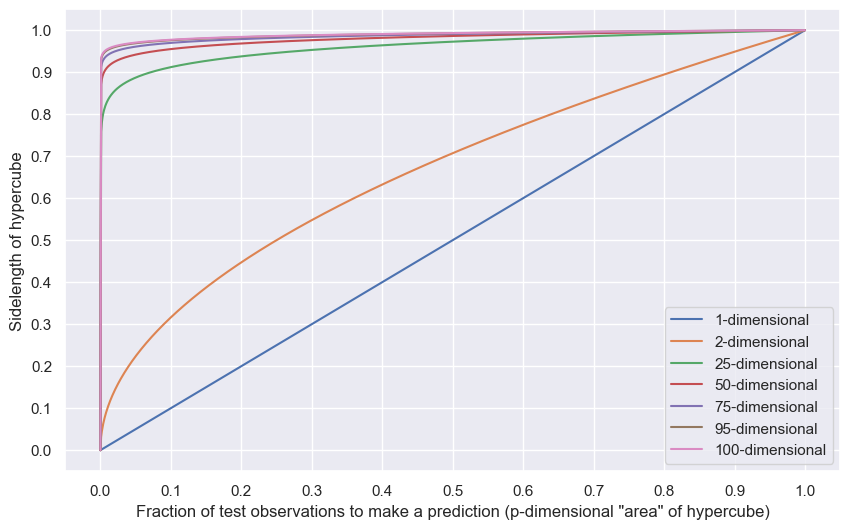

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for p in [1, 2, 25, 50, 75, 95, 100]:
    x = np.linspace(0, 1, 1001)
    ax.plot(x, np.power(x, 1/p), label=f'{p}-dimensional')

ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel('Fraction of test observations to make a prediction (p-dimensional "area" of hypercube)')
ax.set_ylabel('Sidelength of hypercube')
ax.legend();